# 📘 AI/ML Assignment 3
## Supervised Learning Models in Practice

**Total Marks: 100**  
**Submission Format:** Single Jupyter Notebook (`.ipynb`)

---
## 📌 General Instructions (Read Carefully)

- This assignment covers **Modules 13–18**.
- Use **Python and scikit-learn only**.
- Do NOT use AutoML, deep learning, or external ML libraries.
- Fix `random_state=42` wherever applicable.
- Plots must be labeled and readable.
- Do not delete or rename cells.

***Classification Dataset:*** https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data

***Regresssion Dataset:*** https://www.kaggle.com/datasets/mirichoi0218/insurance

## 🔧 TODO 0: Environment Setup (5 Marks)
**Marks Breakdown:**
- Correct imports (3)
- Clean setup, no unused imports (2)


In [ ]:
# TODO: Import all necessary libraries here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


# 🔵 PART A: Regression Task (45 Marks)
You will work with the provided **regression dataset**.


## TODO A1: Dataset Loading and Understanding (5 Marks)
**You must:**
- Load the dataset
- Show shape and column names
- Identify target variable

**Marks:** Data loading (2), Explanation (3)


In [ ]:
# TODO: Load regression dataset
df = pd.read_csv("insurance.csv")
print("Shape: ", df.shape)
print("Columns: ", df.columns.tolist())

Shape:  (1338, 7)
Columns:  ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


Explanation:- Dataset loaded successfully. It contains customer information such as age, sex, bmi, number of children, smoking status, region, and insurance charges. The target variable is charges, because the goal is to predict insurance charges from the other features.

## TODO A2: Exploratory Data Analysis (EDA) (5 Marks)
**You must:**
- Show descriptive statistics
- Plot correlation heatmap
- Plot at least one feature vs target

**Marks:** Plots (3), Interpretation (2)


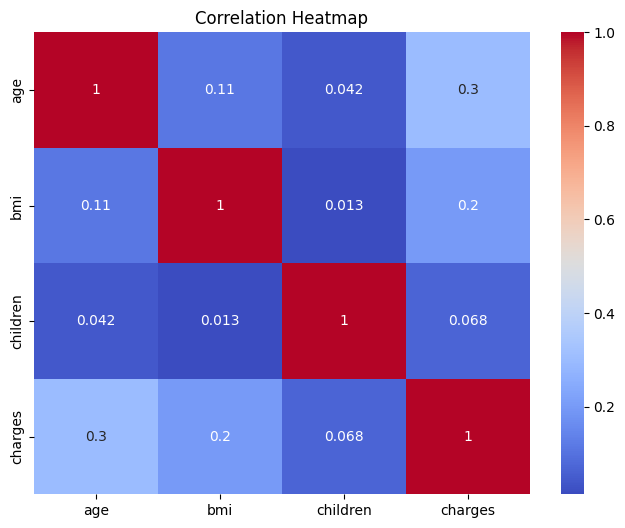

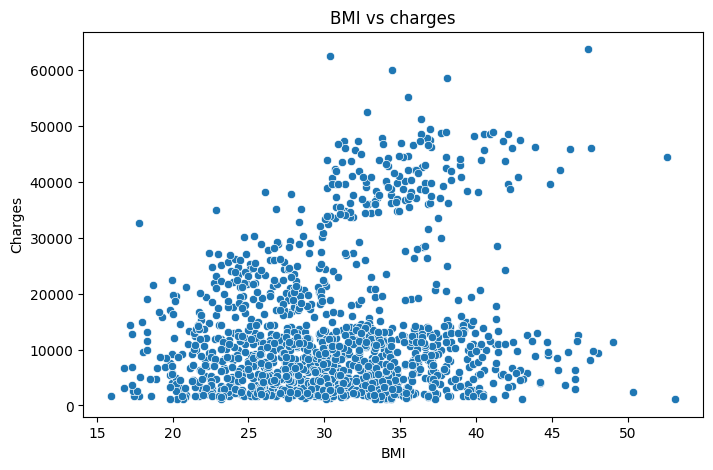

In [ ]:
# TODO: Perform EDA
#descriptive statistics
df.describe()

#correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Feature vs target
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title("BMI vs charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

Interpretation:
- The descriptive statistics provide a summary of the numerical features in the dataset.
- The heatmap shows the relationships between numerical variables. Features with higher correlation values have a stronger relationship with the target.
- The scatter plot suggests that insurance charges generally tend to increase as BMI increases, although there is some variation in the data.


## TODO A3: Feature Preparation (5 Marks)
**You must:**
- Train-test split
- Scaling (if applicable)

**Marks:** Correct split (3), Explanation (2)


In [ ]:
# TODO: Prepare features
X = df.drop("charges", axis=1)
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:",X_train.shape)
print("Test shape:",X_test.shape)

Train shape: (1070, 6)
Test shape: (268, 6)


Explanation: Dataset is split into training and testing sets so the model can learn from one part and be evaluated on unseen data. Here, 80% data is used for training and 20% for testing. This helps to measure real model performance and avoid overfitting.

## TODO A4: Multiple Linear Regression (8 Marks)
**You must:**
- Train model
- Evaluate using RMSE, MAE, R²

**Marks:** Model (4), Metrics (4)


In [ ]:
# TODO: Multiple Linear Regression

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4181.19447375365
RMSE: 5796.284659276273
R2 Score: 0.7835929767120724


## TODO A5: Polynomial Regression (7 Marks)
**You must:**
- Apply polynomial features
- Compare with linear regression

**Marks:** Implementation (4), Comparison (3)


In [ ]:
# TODO: Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size = 0.2, random_state=42
)
poly_model = LinearRegression()
poly_model.fit(X_train, y_train)

y_pred_poly = poly_model.predict(X_test)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly = r2_score(y_test, y_pred_poly)

print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R2 Score:", r2_poly)

MAE: 2729.50013363945
RMSE: 4551.132385233207
R2 Score: 0.8665830903164832


## TODO A6: Support Vector Regression (7 Marks)
**You must:**
- Train SVR (RBF kernel)
- Evaluate performance
- Justify kernel choice

**Marks:** Model (4), Justification (3)


In [ ]:
# TODO: Support Vector Regression
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).ravel()

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)
# SVR Model
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)

mae_svr = mean_absolute_error(y_test, y_pred)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_svr = r2_score(y_test, y_pred)

print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R2 Score:", r2_svr)

MAE: 0.20384716829185479
RMSE: 0.3816887207934823
R2 Score: 0.8624834467579636


Justification: The RBF kernel is used because it can capture non-linear relationships in the data. In this dataset, the relationship between features and insurance charges is not strictly linear, so RBF performs better in handling complex patterns compared to a linear kernel.

## TODO A7: Random Forest Regressor (8 Marks)
**You must:**
- Train Random Forest
- Evaluate model

**Marks:** Model (4), Evaluation (4)


In [ ]:
# TODO: Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 0.20964673287418983
RMSE: 0.3752608063081651
R2 Score: 0.8670762023874213


Explanation:- Random Forest uses many decision trees and averages their outputs. This makes the prediction more stable and reduces errors compared to a single tree.

# 🟠 PART B: Classification Task (45 Marks)
You will work with the provided **classification dataset**.


## TODO B1: Dataset Understanding (5 Marks)
**You must:**
- Load dataset
- Show class distribution
- Comment on imbalance

**Marks:** Analysis (3), Explanation (2)


In [ ]:
# TODO: Load classification dataset
df_cls = pd.read_csv("loan_data.csv")
df_cls.head()

print(df_cls["loan_status"].value_counts())

loan_status
0    35000
1    10000
Name: count, dtype: int64


Explanation:- This dataset is used to predict whether a loan will be approved or not.
We checked the class distribution to see if the dataset is balanced or imbalanced. If one class is much larger than the other, it means the dataset is imbalanced.

## TODO B2: Exploratory Data Analysis (5 Marks)
**You must:**
- Plot class counts
- Plot at least one feature vs class

**Marks:** Plots (5),


loan_status
0    35000
1    10000
Name: count, dtype: int64


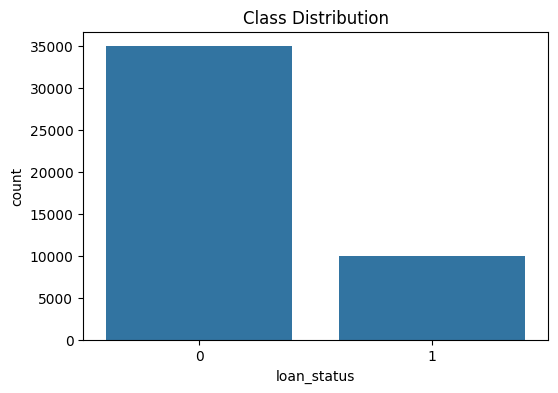

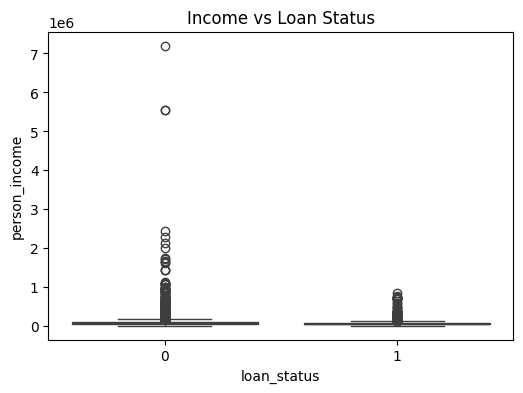

In [ ]:
# TODO: Classification EDA
print(df_cls["loan_status"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="loan_status", data=df_cls)
plt.title("Class Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="loan_status", y="person_income", data=df_cls)
plt.title("Income vs Loan Status")
plt.show()

## TODO B3: Feature Preparation (5 Marks)
**You must:**
- Encoding (if needed)
- Scaling
- Train-test split with stratification




In [ ]:
# TODO: Prepare classification features
X = df_cls.drop("loan_status", axis=1)
y = df_cls["loan_status"]

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (36000, 22)
Test shape: (9000, 22)


## TODO B4: Logistic Regression with L2 (8 Marks)
**You must:**
- Train Logistic Regression
- Evaluate using Accuracy, Precision, Recall
- Show Confusion Matrix

**Marks:** Model (4), Metrics (4)


In [ ]:
# TODO: Logistic Regression
model = LogisticRegression(max_iter = 1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("Confusion Matrix:\n", cm)

Accuracy: 0.8854444444444445
Precision: 0.8841664691590071
Recall: 0.8854444444444445
Confusion Matrix:
 [[6518  482]
 [ 549 1451]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## TODO B5: Support Vector Machine (7 Marks)
**You must:**
- Train SVM (Linear or RBF)
- Evaluate

**Marks:** Model (4), Evaluation (3)


In [ ]:
# TODO: SVM Classification
svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, average="weighted")
rec_svm = recall_score(y_test, y_pred_svm, average="weighted")

print("Accuracy:", acc_svm)
print("Precision:", prec_svm)
print("Recall:", rec_svm)

Accuracy: 0.805
Precision: 0.8158080896324655
Recall: 0.805


## TODO B6: Naive Bayes (5 Marks)
**You must:**
- Choose correct NB variant



In [ ]:
# TODO: Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb, average="weighted")
rec_nb = recall_score(y_test, y_pred_nb, average="weighted")

print("Accuracy:", acc_nb)
print("Precision:", prec_nb)
print("Recall:", rec_nb)

Accuracy: 0.806
Precision: 0.7843199324680806
Recall: 0.806


## TODO B7: K-Nearest Neighbors (5 Marks)
**You must:**
- Try multiple K values
- Plot accuracy vs K

**Marks:** Experiment (3), Plot & choice (2)


In [ ]:
# TODO: KNN
k_values = range(1, 21)
accuracies = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_knn))

# Best K
best_k = k_values[np.argmax(accuracies)]
print("K:", best_k)
print("Best Accuracy:", max(accuracies))

K: 10
Best Accuracy: 0.8426666666666667


## TODO B8: Random Forest Classifier (5 Marks)
**You must:**
- Train model
- Show feature importance

**Marks:** Model (3), Interpretation (2)


In [ ]:
# TODO: Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

importances = rf_clf.feature_importances_
features = X_train.columns

sorted_idx = np.argsort(importances)[::-1]

for i in sorted_idx:
    print(features[i], ":", importances[i])

previous_loan_defaults_on_file_Yes : 0.21812740172971354
loan_percent_income : 0.16379316863850876
loan_int_rate : 0.1574008403007456
person_income : 0.12454911285284655
loan_amnt : 0.061482237222778825
person_home_ownership_RENT : 0.056363703372995004
credit_score : 0.05449156918553346
person_age : 0.031960903943209856
person_emp_exp : 0.028428505368259593
cb_person_cred_hist_length : 0.026421373466678062
person_home_ownership_OWN : 0.009665621764931721
loan_intent_HOMEIMPROVEMENT : 0.009479970338674473
loan_intent_VENTURE : 0.008158869094944154
person_gender_male : 0.008088000237851379
loan_intent_EDUCATION : 0.0076308689636945225
loan_intent_MEDICAL : 0.0075546111398404475
person_education_Bachelor : 0.006583286454724131
loan_intent_PERSONAL : 0.006416786472502314
person_education_High School : 0.006314429067339002
person_education_Master : 0.00513853783982361
person_education_Doctorate : 0.0012535831731976185
person_home_ownership_OTHER : 0.0006966193712075351


# 🧠 Final Reflection (5 Marks)
**Answer briefly:**
- Best regression model and why
- Best classification model and why
- One real-world deployment scenario


## TODO:
- Random Forest Regressor performed best because it handles complex patterns better and gives more stable predictions than linear models.
- Random Forest Classifier performed best because it reduces overfitting and works well with mixed types of features.
- This model can be used in banks to automatically decide whether a loan should be approved based on customer information.